In [1]:
import os
import xarray as xr
import numpy as np
import itertools
import pandas as pd
from pathlib import Path
from datetime import datetime
import geopandas as gpd
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import ssam_groups as groups
import ssam_plot as splot
from mpl_toolkits.axes_grid1 import make_axes_locatable

### Define scenario and control files

In [2]:
hex_colour = '#6DB48E'
hatches = ['oo', '///', 'xx', '++']

In [3]:
# Reading in Atlantis map
shapefile_name = "/ocean/rlovindeer/Atlantis/ssam_oceanparcels/SalishSea/SalishSea_July172019_2/SalishSea_July172019.shp"
data_df_original = gpd.read_file(shapefile_name)
data_df_original = data_df_original.sort_values(by=['BOX_ID'])
data_df = data_df_original.set_index('BOX_ID')
box_depth = data_df['BOTZ']
land_boxes = box_depth==0
land_boxes = data_df.index[land_boxes]
land_df = data_df.loc[land_boxes]
jdf_df = data_df.loc[data_df.Region=='Juan de Fuca']
hs_df = data_df.loc[data_df.Region=='Howe Sound']
strait_df = data_df.loc[data_df.Region=='Strait of Georgia']
ps_df = data_df.loc[data_df.Region=='Puget Sound']

5b Simulation Date 2020-01-16 affected boxes BOX_ID
1     655575973
5     261808665
33    181216243
34    116214640
60    322474724
66    130534737
Name: AREA, dtype: int64
5b Simulation Date 2019-01-14 affected boxes BOX_ID
1     655575973
2     682702420
5     261808665
8     485601055
9     288060859
33    181216243
60    322474724
Name: AREA, dtype: int64
5b Simulation Date 2020-01-24 affected boxes BOX_ID
5     261808665
8     485601055
9     288060859
33    181216243
60    322474724
Name: AREA, dtype: int64
5b Simulation Date 2019-01-20 affected boxes BOX_ID
1     655575973
2     682702420
3     494069246
4     446328916
5     261808665
8     485601055
9     288060859
33    181216243
34    116214640
37     61024272
60    322474724
Name: AREA, dtype: int64
5b Simulation Date 2019-04-12 affected boxes BOX_ID
33    181216243
34    116214640
60    322474724
68     85349880
Name: AREA, dtype: int64
5b Simulation Date 2019-04-06 affected boxes BOX_ID
9     288060859
33    181216243
34 

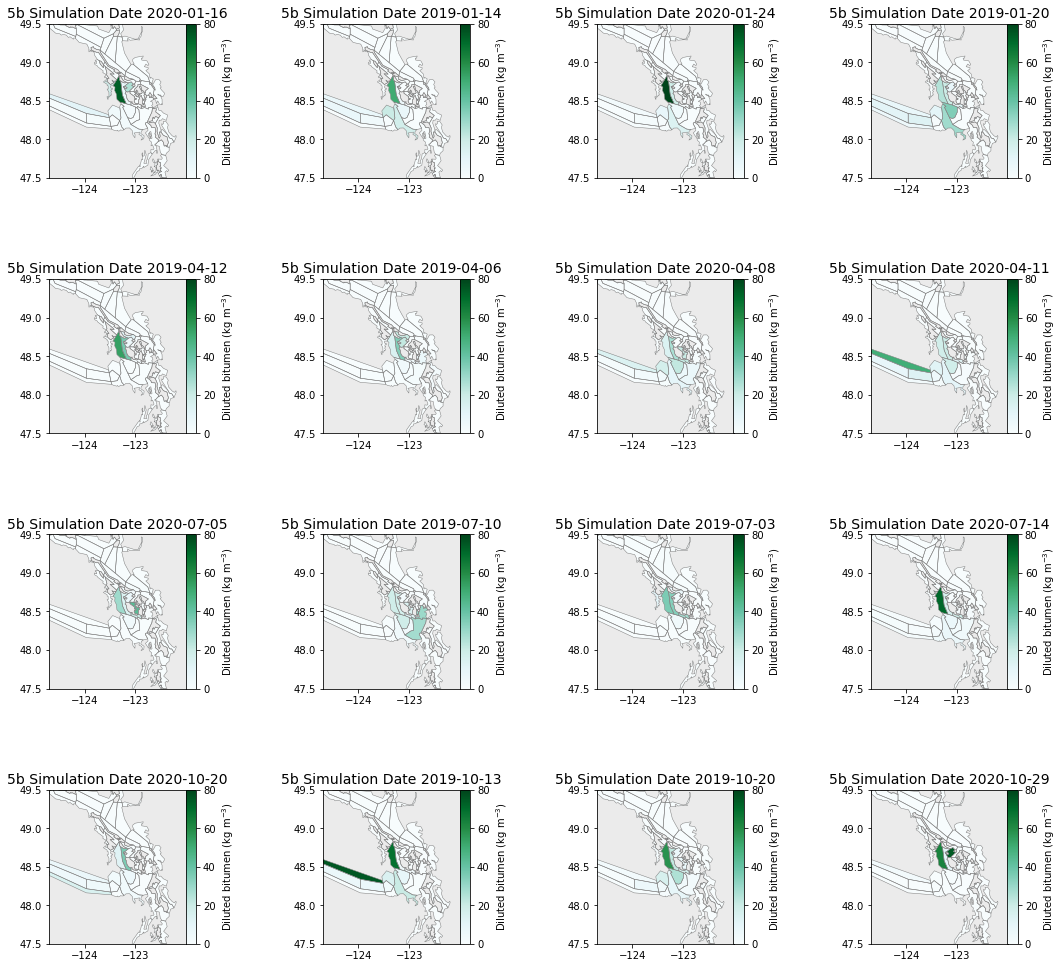

In [13]:
# Oil injection file 
oil_root = Path('/ocean/rlovindeer/MOAD/analysis-raisha/notebooks/contaminant-dispersal/results/')
#oil_paths = sorted([p for p in oil_root.glob('SSAM_Scenario_5b_*_alkyls.nc')]) # SSAM_Scenario_6a_2019-07-25_10000_alkyls.nc
oil_paths = sorted(oil_root.glob("SSAM_Scenario_5b_*_alkyls.nc"),key=lambda p: int(p.name.split("_")[3].split("-")[1]))
oil_files = [xr.open_dataset(oil_scen,decode_cf=True) for oil_scen in oil_paths]

fig = plt.figure(figsize=(18, 18), facecolor='white') #figsize=(9, 12)
gs = plt.GridSpec(4, 4, wspace=0.5, hspace=0.2, height_ratios=[1,1,1,1],)

position = 0
row = 0

for file, oil_path in zip(oil_files, oil_paths):
    date = str(oil_path).split(sep = '_')[3]
    code = str(oil_path).split(sep = '_')[2]
    label = str(code) +' Simulation Date '+ str(date)
    #label = oil_path.stem
    oil_tb = file.variables['oil']
    oil_b = oil_tb.mean(axis=0)

    # Add scenario data to Atlantis spatial data
    data_df['oil'] = oil_b
    data_df.loc[land_boxes, 'oil'] = 0
    oil_df = data_df.loc[data_df['oil'] > 4] #5% of maximum
    print(label,'affected boxes',oil_df.AREA)

    ax = fig.add_subplot(gs[row, position], facecolor = '#EBEBEB')
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=-0.5)
    ax = data_df.plot(column = 'oil', ax=ax, cax=cax,cmap=cm.BuGn, legend_kwds={'label': 'Diluted bitumen (kg m$^{-3}$)'}, vmax=80,
    #ax = data_df.plot(column = 'BOTZ', ax=ax, cax=cax,cmap=cm.Blues, legend_kwds={'label': 'depth (m)'},
    legend=True, 
    )
    ax.set_title(label, fontsize = 14)
    ax.set_xlim(-124.7)
    ax.set_ylim(47.5, 49.5)
    data_df.boundary.plot(ax=ax, color='grey', linewidths=0.5)
    land_df.plot(ax=ax, color='#EBEBEB')
    #oil_df.plot(ax=ax, color='red',linewidths=0.5)
    position = position+1
    if position == 4:
        row = row+1
        position = 0

English Bay Simulation #2 affected boxes Series([], Name: AREA, dtype: int64)


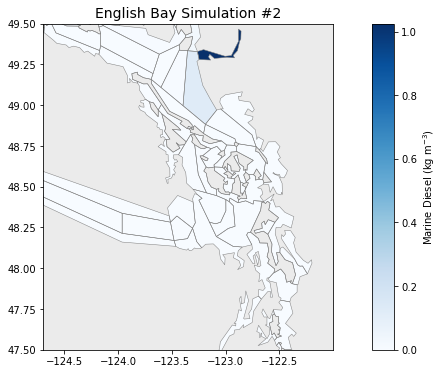

In [ ]:
# Oil injection file 
oil_root = Path('/ocean/rlovindeer/MOAD/analysis-raisha/notebooks/contaminant-dispersal/results/')
oil_paths = sorted([p for p in oil_root.glob('SSAM_Scenario_6b_*_alkyls.nc')]) # 
oil_files = [xr.open_dataset(oil_scen,decode_cf=True) for oil_scen in oil_paths]

hex_colour = '#863092'

fig = plt.figure(figsize=(18, 6), facecolor='white') #figsize=(9, 12)
gs = plt.GridSpec(1, len(oil_files), wspace=0.5, hspace=0.2, height_ratios=[1],)

position = 0

for file, oil_path in zip(oil_files, oil_paths):
    date = str(oil_path).split(sep = '_')[3]
    code = str(oil_path).split(sep = '_')[2]
    label = groups.locations[code] +' Simulation #'+ str(groups.simulations[groups.conditions[date]])
    oil_tb = file.variables['oil']
    oil_b = oil_tb.mean(axis=0)

    # Add scenario data to Atlantis spatial data
    data_df['oil'] = oil_b
    data_df.loc[land_boxes, 'oil'] = 0
    oil_df = data_df.loc[data_df['oil'] > 4] #5% of maximum
    print(label,'affected boxes',oil_df.AREA)

    ax = fig.add_subplot(gs[0, position], facecolor = '#EBEBEB')
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=-0.5)
    ax = data_df.plot(column = 'oil', ax=ax, cax=cax,cmap=cm.Blues, legend_kwds={'label': 'Marine Diesel (kg m$^{-3}$)'}, vmax=None,
    #ax = data_df.plot(column = 'BOTZ', ax=ax, cax=cax,cmap=cm.Blues, legend_kwds={'label': 'depth (m)'},
    legend=True, 
    )
    ax.set_title(label, fontsize = 14)
    ax.set_xlim(-124.7)
    ax.set_ylim(47.5, 49.5)
    data_df.boundary.plot(ax=ax, color='grey', linewidths=0.5)
    land_df.plot(ax=ax, color='#EBEBEB')
    #oil_df.plot(ax=ax, color='red',linewidths=0.5)
    position = position+1